In [1]:
import sys
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt


# Quantum Fourier Transform (QFT) Algorithm

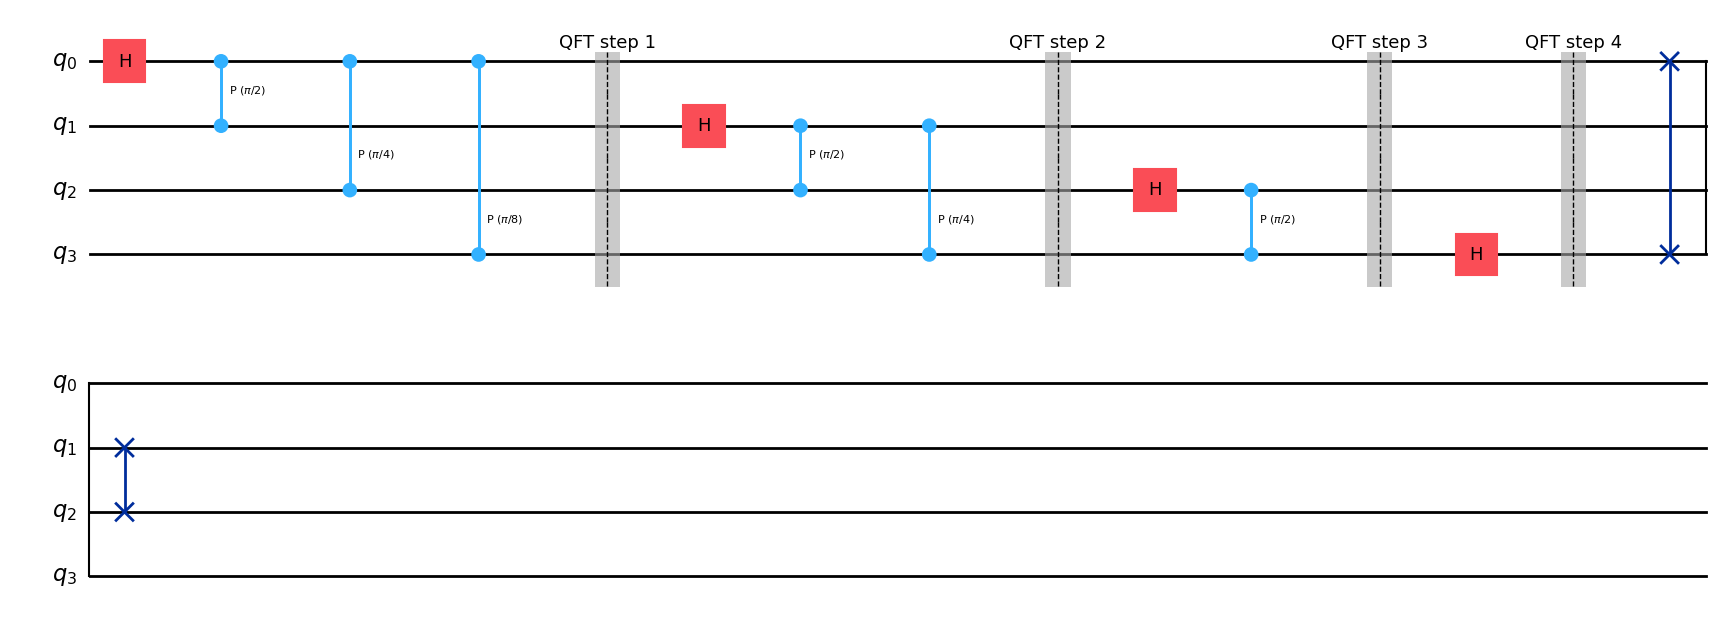

In [8]:
def newQFT(n):
    qc = QuantumCircuit(n)
    
    for j in range(n):
        qc.h(j)
        for k in range(j+1, n):
            qc.cp(np.pi / 2**(k-j), k, j)
        qc.barrier(label=f"QFT step {j+1}")

    # Swap
    for i in range(n // 2):
        qc.swap(i, n - i - 1)
    return qc

# Example
n = 4  # Number of qubits
"""
if len(sys.argv) > 1:
    n = int(sys.argv[1])
"""
qft_circuit = newQFT(n)
qft_circuit.name = "QFT"
qft_circuit.draw('mpl')
# plt.show()

In [15]:
plt.show()

# Deutsch-Jozsa Algorithm Implementation

Here the oracle is simply having 2 qubits with multiple cases for constant and balanced functions.

In [16]:

def deutsch(case: str):
    qc = QuantumCircuit(2,1)
    qc.x(1)
    qc.h([0, 1])
    qc.append(oracle_deutsch(case), [0, 1])
    qc.h(0)
    qc.measure(0, 0)
    print("Deutsch Circuit:")
    print(qc.draw())

    sim = Aer.get_backend("qasm_simulator")
    result = sim.run(transpile(qc, sim), shots=1024).result()
    counts = result.get_counts()
    print("Measurement Results:", counts)
    # plt.show()
    print("The function is", "constant" if '0' in counts and len(counts) == 1 else "balanced")

def oracle_deutsch(case : str) -> QuantumCircuit:
    oracle_qc = QuantumCircuit(2)
    if case == "const0":
        pass # Identity operation
    elif case == "const1":
        oracle_qc.x(1)  # Flip the output qubit
    elif case == "bal01":
        oracle_qc.cx(0, 1)
    elif case == "bal10":
        oracle_qc.cx(0, 1)
        oracle_qc.x(1)
    else:
        raise ValueError("Invalid case specified for oracle_deutsch.")

    return oracle_qc

if __name__ == "__main__":
    # Run
    deutsch("const0")
    deutsch("bal01")
    deutsch("const1")
    deutsch("bal10")

Deutsch Circuit:
     ┌───┐     ┌──────────────┐┌───┐┌─┐
q_0: ┤ H ├─────┤0             ├┤ H ├┤M├
     ├───┤┌───┐│  circuit-118 │└───┘└╥┘
q_1: ┤ X ├┤ H ├┤1             ├──────╫─
     └───┘└───┘└──────────────┘      ║ 
c: 1/════════════════════════════════╩═
                                     0 
Measurement Results: {'0': 1024}
The function is constant
Deutsch Circuit:
     ┌───┐     ┌──────────────┐┌───┐┌─┐
q_0: ┤ H ├─────┤0             ├┤ H ├┤M├
     ├───┤┌───┐│  circuit-123 │└───┘└╥┘
q_1: ┤ X ├┤ H ├┤1             ├──────╫─
     └───┘└───┘└──────────────┘      ║ 
c: 1/════════════════════════════════╩═
                                     0 
Measurement Results: {'1': 1024}
The function is balanced
Deutsch Circuit:
     ┌───┐     ┌──────────────┐┌───┐┌─┐
q_0: ┤ H ├─────┤0             ├┤ H ├┤M├
     ├───┤┌───┐│  circuit-128 │└───┘└╥┘
q_1: ┤ X ├┤ H ├┤1             ├──────╫─
     └───┘└───┘└──────────────┘      ║ 
c: 1/════════════════════════════════╩═
                                 

# Deutsch-Jozsa Algorithm Implementation

In [19]:

def oracle_d_jozsa(case : str, n : int) -> QuantumCircuit:
    oracle_qc = QuantumCircuit(n + 1)
    if case == "const0":
        pass # Identity operation
    elif case == "const1":
        oracle_qc.x(n)  # Flip the output qubit
    elif case.startswith("bal"):
        for i in range(n):
            # if case[i+3] == '1':
            oracle_qc.cx(i, n)
    else:
        raise ValueError("Invalid case specified for oracle_d_jozsa.")

    return oracle_qc


def deutsch_jozsa(n: int, case: str):
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n+1))
    qc.barrier()
    qc.append(oracle_d_jozsa(case, n),range(n+1))
    qc.h(range(n))
    qc.barrier()
    qc.measure(range(n),range(n))


    print("Deutsch-Jozsa Circuit:")
    print(qc.draw())
    # plt.show()
    # compiled = transpile(qc, sim)
    sim = Aer.get_backend('qasm_simulator')
    result = sim.run(transpile(qc, sim), shots=16).result()
    counts = result.get_counts()
    print(counts)
        # plot_histogram(counts)
        # plt.show()
    print("The function is", "constant" if '0'*n in counts and len(counts) == 1 else "balanced")



if __name__ == "__main__":
    """if len(sys.argv) > 2:
        n = int(sys.argv[1])
        case = sys.argv[2]
        deutsch_jozsa(n, case)
    else:"""
        # Example run 
    print("Running Deutsch-Jozsa for n=4, balanced function 'bal0'")
    deutsch_jozsa(4,"bal0")


Running Deutsch-Jozsa for n=4, balanced function 'bal0'
Deutsch-Jozsa Circuit:
     ┌───┐      ░ ┌──────────────┐┌───┐ ░ ┌─┐         
q_0: ┤ H ├──────░─┤0             ├┤ H ├─░─┤M├─────────
     ├───┤      ░ │              │├───┤ ░ └╥┘┌─┐      
q_1: ┤ H ├──────░─┤1             ├┤ H ├─░──╫─┤M├──────
     ├───┤      ░ │              │├───┤ ░  ║ └╥┘┌─┐   
q_2: ┤ H ├──────░─┤2 circuit-148 ├┤ H ├─░──╫──╫─┤M├───
     ├───┤      ░ │              │├───┤ ░  ║  ║ └╥┘┌─┐
q_3: ┤ H ├──────░─┤3             ├┤ H ├─░──╫──╫──╫─┤M├
     ├───┤┌───┐ ░ │              │└───┘ ░  ║  ║  ║ └╥┘
q_4: ┤ X ├┤ H ├─░─┤4             ├──────░──╫──╫──╫──╫─
     └───┘└───┘ ░ └──────────────┘      ░  ║  ║  ║  ║ 
c: 4/══════════════════════════════════════╩══╩══╩══╩═
                                           0  1  2  3 
{'1111': 16}
The function is balanced
